In [2]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv

In [3]:
load_dotenv()

True

In [4]:
model = ChatOpenAI()

In [5]:
class LLMState(StateGraph):
    que: str
    ans: str

In [6]:
def llm_qa(state:LLMState) -> LLMState:
    # extract the question form the state
    que = state['que']

    # prompt generating
    prompt = f'Ans the following ques {que}'

    # giving prompt to the llm
    ans = model.invoke(prompt).content

    # update the ans in the state
    state['ans'] = ans

    return state

In [7]:
graph = StateGraph(LLMState)

# add nodes
graph.add_node('llm_qa', llm_qa)

# add edges 
graph.add_edge(START,'llm_qa')
graph.add_edge('llm_qa',END)

# compile 
workflow = graph.compile()

In [8]:
# execute
initial_state = {'que':'How far is moon from the earth'}
final_state = workflow.invoke(initial_state)

print(final_state['ans'])

AuthenticationError: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-or-v1*************************************************************de43. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}

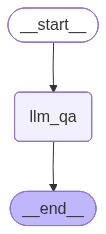

In [ ]:
## to see the graph 
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [ ]:
model.invoke('How far is moon from the earth?').content



"The average distance from the Earth to the Moon is about 238,855 miles (384,400 kilometers). This distance can vary slightly due to the Moon's elliptical orbit around the Earth. At its closest point (perigee), the Moon can be about 225,623 miles (363,104 kilometers) away, and at its farthest point (apogee), it can be about 252,088 miles (405,696 kilometers) away."